### 1. A nasty integral

Using Monte Carlo integration, check that

$$ \int_0^\infty x^3 \exp\left(-\frac{x^2}{2\sigma^2}\right) \,dx = 2\sigma^4 .$$

- Does the result converge with the number of samples? And how does the error go down?
- Do it many times. For a given $N$, how are the result distributed? We'll talk about model fitting at lenght later on, but for now try to fit it by hand with a parametrized model. (If N is large enough you should get something that looks *very* accurate! And if $N$ is small?)
- How does the distribution change if $N$ increases?

(Hint: think about sample mean and sample variance)


In [57]:
#Implementiamo le librerie
import numpy as np
import scipy.stats
import pylab as plt


from sklearn.mixture import GaussianMixture

from scipy.stats import norm #per la gaussiana

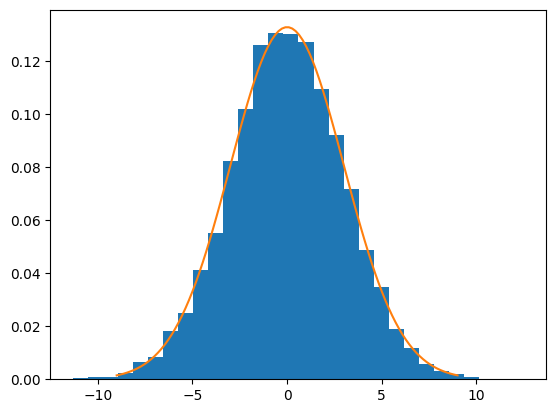

In [48]:
N = int(1e4) #numero di samples
sigma = 3 #sigma della gaussiana

#usiamo scipy per creare la pdf
gauss = scipy.stats.norm(loc = 0, scale = sigma) #la media è 0

plt.hist(gauss.rvs(N), density = True, bins = 30)
x_ax = np.linspace(-3*sigma, 3*sigma, 100)
plt.plot(x_ax, gauss.pdf(x_ax))

In [49]:
#estriamo i samples
samples = gauss.rvs(N)
integral = (sigma*np.sqrt(2*np.pi)*np.mean(np.abs(samples)**3))/2 #faccio il valore assoluto e poi divido per due (sto considerando solo la gaussiana da 0 a +inf)
estimated_result = 2*(sigma**4)

print(integral)
print(estimated_result)

159.19240910578185
162


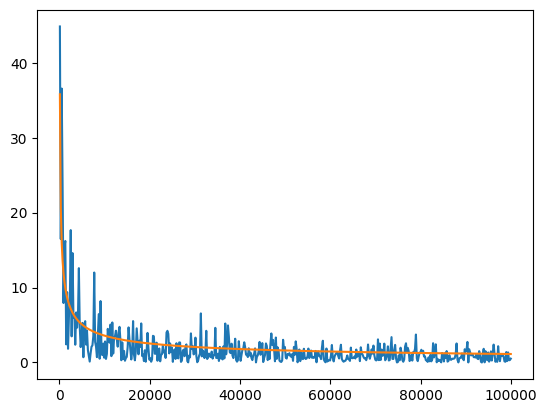

In [50]:
#Ci aspettiamo dalla teoria un errore che descresce come l'inverso  di sqrt(N) 

def integration(sigma, N):
    gauss = scipy.stats.norm(loc = 0, scale=sigma)
    samples = gauss.rvs(N)
    integral = (sigma*np.sqrt(2*np.pi)*np.mean(np.abs(samples)**3))/2
    estimated = 2*sigma**4
    error = np.abs(integral - estimated)
    return integral, error

#creiamo un array di valori N di int tra 100 e 1e5 con 500 di step
N_array = np.round(np.linspace(100, 1e5, 500)).astype(int)
integral = []
error = []
estimated = 2*(sigma**4)
for n in N_array:
    int_val, error_val = integration(sigma,n)
    integral.append(int_val)
    error.append(error_val)
    
integral = np.array(integral)
error = np.array(error)

plt.plot(N_array, error)

#facciamo la curva teorica
x_ax = np.linspace(100, 1e5, 500)
y_ax = 358/(np.sqrt(x_ax))

plt.plot(x_ax, y_ax)

#Facciamo la parte 3 "- Do it many times. For a given $N$, how are the result distributed? We'll talk about model fitting at lenght later on, but for now try to fit it by hand with a parametrized model. (If N is large enough you should get something that looks *very* accurate! And if $N$ is small?)"

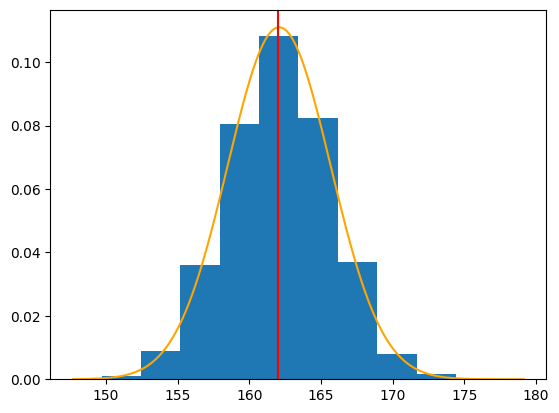

In [60]:
#per un N grande
N = int(1e4) #samples
trials = int(1e4) #quante volte viene fatto l'integrale
integral = []
for i in range(trials):
    int_val, error = integration(sigma, N)
    integral.append(int_val)

integral = np.array(integral)

plt.hist(integral, density = True)

#facciamo il fit con la gaussian mixture che è parametrico
xgrid = np.linspace(integral.min() - 2, integral.max() +2, 1000).reshape(-1,1)
gmm = GaussianMixture(n_components=1).fit(integral.reshape(-1,1)) #usiamo una sola componente
logprob = gmm.score_samples(xgrid)
fx = np.exp(logprob)
plt.plot(xgrid,fx, color = 'orange')
plt.axvline(2*(sigma**4), color = 'red')

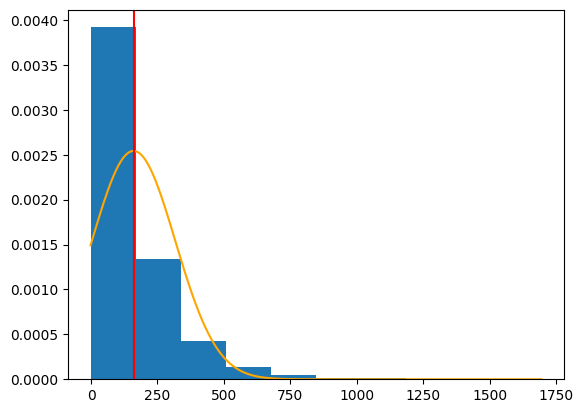

In [63]:
#per un N piccolo non mi aspetto una gaussiana perfetta
N = int(5) #samples
trials = int(1e4) #quante volte viene fatto l'integrale
integral = []
for i in range(trials):
    int_val, error = integration(sigma, N)
    integral.append(int_val)

integral = np.array(integral)

plt.hist(integral, density=True)

#facciamo il fit con la gaussian mixture che è parametrico
xgrid = np.linspace(integral.min() - 2, integral.max() +2, 1000).reshape(-1,1)
gmm = GaussianMixture(n_components=1).fit(integral.reshape(-1,1)) #usiamo una sola componente
logprob = gmm.score_samples(xgrid)
fx = np.exp(logprob)
plt.plot(xgrid,fx, color = 'orange')
plt.axvline(2*(sigma**4), color = 'red')